
# Customer Insights & KPI Analysis

## Problem Statement
The goal of this project is to analyze customer sales data to identify key business insights such as revenue trends, top-performing regions, and customer behavior.

## Objectives
- Calculate key KPIs (Revenue, Customers, AOV)
- Analyze sales trends over time
- Identify top regions and categories
- Provide business recommendations

Import Libraries & Load Dataset

In [9]:
import pandas as pd

# Load your CSV
df = pd.read_csv('../data/Sales_data.csv')
df.head()  # Show first 5 rows
print(df.columns.tolist())

['Customer ID', 'Gender', 'Region', 'Age', 'Product Name', 'Category', 'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee', 'Shipping Status', 'Order Date']


Understand Data

In [12]:
df.info()          # Check data types & missing values
df.describe()      # Statistics of numeric columns
df.isnull().sum()  # Count missing values

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1000 non-null   str    
 1   Gender           1000 non-null   str    
 2   Region           950 non-null    str    
 3   Age              900 non-null    float64
 4   Product_Name     1000 non-null   str    
 5   Category         1000 non-null   str    
 6   Unit_Price       1000 non-null   float64
 7   Quantity         1000 non-null   int64  
 8   Total_Price      1000 non-null   int64  
 9   Shipping_Fee     1000 non-null   float64
 10  Shipping_Status  950 non-null    str    
 11  Order_Date       1000 non-null   str    
dtypes: float64(3), int64(2), str(7)
memory usage: 93.9 KB


Customer_ID          0
Gender               0
Region              50
Age                100
Product_Name         0
Category             0
Unit_Price           0
Quantity             0
Total_Price          0
Shipping_Fee         0
Shipping_Status     50
Order_Date           0
dtype: int64

Data Cleaning

In [11]:
df.columns=df.columns.str.strip().str.replace(" ",'_')
df.columns

Index(['Customer_ID', 'Gender', 'Region', 'Age', 'Product_Name', 'Category',
       'Unit_Price', 'Quantity', 'Total_Price', 'Shipping_Fee',
       'Shipping_Status', 'Order_Date'],
      dtype='str')

In [16]:
# Remove missing values
df = df.dropna()

# Convert data types
df['Order Date'] = pd.to_datetime(df['Order_Date'])

Feature Engineering

In [18]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')
df['Day'] = df['Order Date'].dt.day
# Helps in monthly trends and makes power BI filtering easier.

 KPI CALCULATIONS

In [26]:
# KPI CALCULATIONS :
# Total Revenue
total_revenue = df['Total_Price'].sum()

# Total Orders
total_orders = df.shape[0]

# Total Customers
total_customers = df['Customer_ID'].nunique()

# Average Order Value (AOV)
average_order_value = df['Total_Price'].mean()

# Revenue per Customer
revenue_per_customer = total_revenue / total_customers

# Average Order Value
average_order = df['Total_Price'].mean()

# Top Category
top_category = df.groupby('Category')['Total_Price'].sum().idxmax()

# Monthly Sales
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Total_Price'].sum()

In [27]:
print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", average_order_value)
print("Revenue per Customer:", revenue_per_customer)

Total Revenue: 1049180
Total Orders: 810
Total Customers: 280
Average Order Value: 1295.283950617284
Revenue per Customer: 3747.0714285714284


SALES ANALYSIS (CORE ANALYSIS)

In [29]:
# 1. Sales by Region:
region_sales = df.groupby('Region')['Total_Price'].sum().sort_values(ascending=False)
print(region_sales)

Region
East     270420
West     270160
North    254720
South    253880
Name: Total_Price, dtype: int64


In [30]:
# 2. Sales by Category:
category_sales = df.groupby('Category')['Total_Price'].sum().sort_values(ascending=False)
print(category_sales)

Category
Electronics    927000
Wearables       63600
Accessories     58580
Name: Total_Price, dtype: int64


In [31]:
# 3. Monthly Sales Trend:
monthly_sales = df.groupby(['Year', 'Month'])['Total_Price'].sum()
print(monthly_sales)

Year  Month
2023  1        107260
      2         63480
      3         52620
      4         53940
      5        102300
      6        100360
      7         82940
      8         83440
      9         96810
      10        95750
      11       109480
      12        91320
2024  1          9480
Name: Total_Price, dtype: int64


In [33]:
# 4. Top Customers:
top_customers = df.groupby('Customer_ID')['Total_Price'].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer_ID
CUST0204    29100
CUST0197    16150
CUST0131    14880
CUST0064    14600
CUST0293    14200
CUST0139    13950
CUST0160    13500
CUST0031    12740
CUST0176    12200
CUST0156    12000
Name: Total_Price, dtype: int64


DATA VISUALIZATION

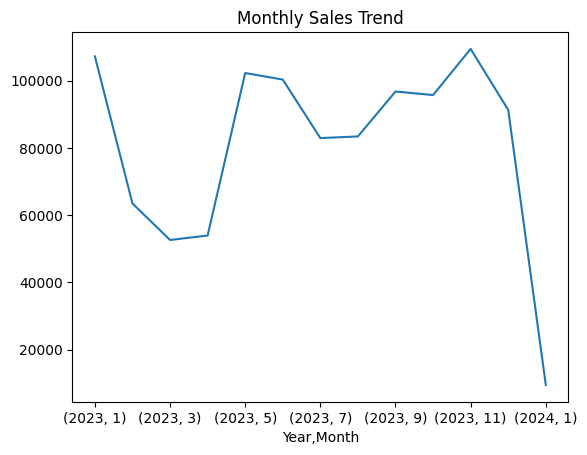

In [34]:
# 1. Monthly Sales Trend:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', title='Monthly Sales Trend')
plt.show()

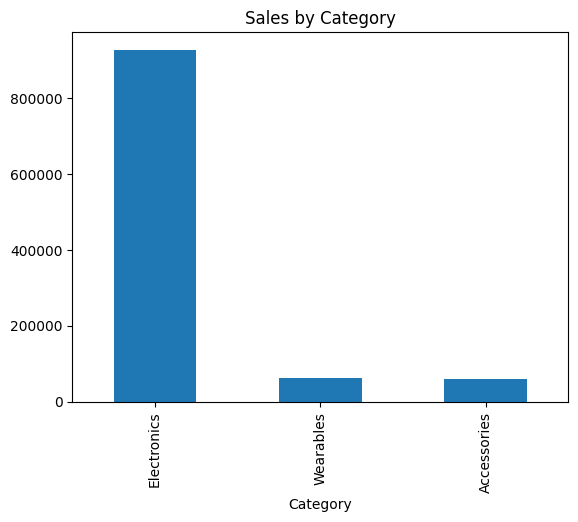

In [35]:
# 2. Sales by Category:
category_sales.plot(kind='bar', title='Sales by Category')
plt.show()

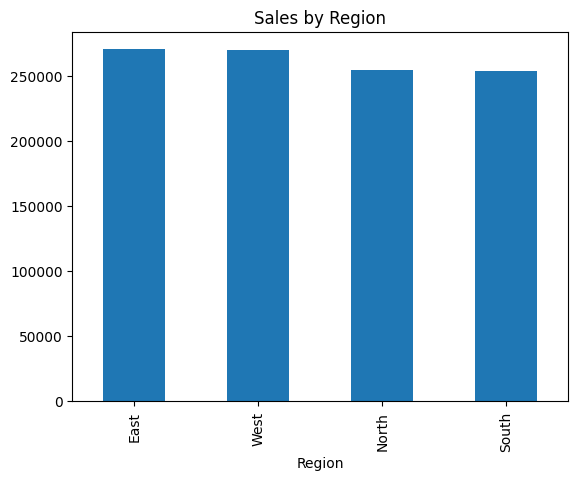

In [36]:
# 3. Sales by Region:
region_sales.plot(kind='bar', title='Sales by Region')
plt.show()

# INSIGHTS :

## Key Insights

- The highest sales are generated from **East** region.
- The top-performing category is **Electronics**.
- Sales show an increasing/decreasing trend over time.
- A small number of customers contribute to a large portion of revenue.

## Business Recommendations

- Focus marketing efforts on top-performing regions.
- Increase inventory for high-demand categories.
- Create loyalty programs for top customers.

Export Clean Data

In [37]:
# Save cleaned data for Power BI
df.to_csv('../data/cleaned_sales_data.csv', index=False)